In [31]:
from pathlib import Path
from rosbags.typesys import get_typestore, Stores, get_types_from_msg
from rosbags.rosbag2 import Reader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [32]:
# --- Configuration ---
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path().resolve()

# Bag recorded while rotating the IMU in a circle (for magnetometer calibration)
BAG_PATH_circle = NOTEBOOK_DIR.parents[1] / "src/data/data_going_in_circles"
# Bag recorded while driving
BAG_PATH_drive  = NOTEBOOK_DIR.parents[1] / "src/data/data_driving"

IMU_TOPIC = "/imu"
GPS_TOPIC = "/gps"

IMU_MSG_PATH = "/home/adrian/EECE5554/LAB4/src/imu_msg/msg/IMUmsg.msg"
IMU_MSG_TYPE = "imu_msg/msg/IMUmsg"

GPS_MSG_PATH = "/home/adrian/EECE5554/LAB4/src/gps_driver_msgs/msg/GpsMsg.msg"
GPS_MSG_TYPE = "gps_driver_msgs/msg/GpsMsg"

In [33]:
typestore = get_typestore(Stores.ROS2_HUMBLE)

def register_msg_file(typestore, msg_path: str, full_type_name: str):
    msg_text = Path(msg_path).read_text()
    add_types = get_types_from_msg(msg_text, full_type_name)
    typestore.register(add_types)

register_msg_file(typestore, IMU_MSG_PATH, IMU_MSG_TYPE)
register_msg_file(typestore, GPS_MSG_PATH, GPS_MSG_TYPE)

In [34]:
def quaternion_to_euler(w, x, y, z):
    """Convert quaternion to Euler angles (roll, pitch, yaw) in degrees."""
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    sinp = 2 * (w * y - z * x)
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = np.arcsin(sinp)

    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    return np.degrees(roll), np.degrees(pitch), np.degrees(yaw)


def bag_to_df_imu(bag_path, typestore, topic: str = "/imu") -> pd.DataFrame:
    rows = []
    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue
            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)

            qx = float(msg.imu.orientation.x)
            qy = float(msg.imu.orientation.y)
            qz = float(msg.imu.orientation.z)
            qw = float(msg.imu.orientation.w)
            roll, pitch, yaw = quaternion_to_euler(qw, qx, qy, qz)

            rows.append({
                "bag_time_ns": int(timestamp),
                "gyro_x":    float(msg.imu.angular_velocity.x),
                "gyro_y":    float(msg.imu.angular_velocity.y),
                "gyro_z":    float(msg.imu.angular_velocity.z),
                "accel_x":   float(msg.imu.linear_acceleration.x),
                "accel_y":   float(msg.imu.linear_acceleration.y),
                "accel_z":   float(msg.imu.linear_acceleration.z),
                "mag_x":     float(msg.mag_field.magnetic_field.x),
                "mag_y":     float(msg.mag_field.magnetic_field.y),
                "mag_z":     float(msg.mag_field.magnetic_field.z),
                "roll_deg":  roll,
                "pitch_deg": pitch,
                "yaw_deg":   yaw,
            })

    df = pd.DataFrame(rows)
    df["time_s"]    = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    df["timestamp"] = df["time_s"]   # alias used in analysis cells
    df["imu_yaw"]   = df["yaw_deg"]  # alias used in analysis cells
    return df


def bag_to_df_gps(bag_path, typestore, topic: str = "/gps") -> pd.DataFrame:
    rows = []
    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue
            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)
            rows.append({
                "bag_time_ns":   int(timestamp),
                "latitude":      float(msg.latitude),
                "longitude":     float(msg.longitude),
                "altitude":      float(msg.altitude),
                "utm_easting":   float(msg.utm_easting),
                "utm_northing":  float(msg.utm_northing),
                "hdop":          float(msg.hdop),
                "utc":           str(msg.utc),
                "zone":          str(msg.zone),
            })
    df = pd.DataFrame(rows)
    df["time_s"] = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    return df

## Load Bags into DataFrames

In [35]:
df_circle = bag_to_df_imu(BAG_PATH_circle, typestore, IMU_TOPIC)
df_circle = df_circle[df_circle['time_s'] > 4500].reset_index(drop=True)

df_drive  = bag_to_df_imu(BAG_PATH_drive,  typestore, IMU_TOPIC)
df_gps    = bag_to_df_gps(BAG_PATH_drive,  typestore, GPS_TOPIC)

print(f"Circle bag: {len(df_circle)} IMU samples, {df_circle['time_s'].iloc[-1]:.1f} s")
print(f"Drive bag:  {len(df_drive)}  IMU samples, {df_drive['time_s'].iloc[-1]:.1f} s")
print(f"Drive bag:  {len(df_gps)}   GPS samples")

Circle bag: 106 IMU samples, 5017.2 s
Drive bag:  1258  IMU samples, 1257.0 s
Drive bag:  1255   GPS samples


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Load your data ---
# df = pd.read_csv('your_data.csv')
mag = df_circle[['mag_x', 'mag_y', 'mag_z']].values  # shape (N, 3)

# ============================================================
# Step 1: Fit a general ellipsoid via least-squares
# 
# General quadric: Ax² + By² + Cz² + 2Dxy + 2Exz + 2Fyz + 2Gx + 2Hy + 2Iz = 1
# We solve for [A, B, C, D, E, F, G, H, I] using least squares
# ============================================================

x, y, z = mag[:, 0], mag[:, 1], mag[:, 2]

# Build the design matrix
D_mat = np.column_stack([
    x**2, y**2, z**2,
    2*x*y, 2*x*z, 2*y*z,
    2*x, 2*y, 2*z
])

# Solve D_mat @ v = 1  (vector of ones)
ones = np.ones(len(x))
v, residuals, rank, sv = np.linalg.lstsq(D_mat, ones, rcond=None)

# ============================================================
# Step 2: Extract ellipsoid parameters
# 
# Reconstruct the quadric matrix Q and offset vector
# Q = [[A, D, E],    g = [G, H, I]
#      [D, B, F],
#      [E, F, C]]
# ============================================================

A_q = np.array([
    [v[0], v[3], v[4]],
    [v[3], v[1], v[5]],
    [v[4], v[5], v[2]]
])
g = np.array([v[6], v[7], v[8]])

# Hard-iron offset: center = -A_q^{-1} @ g
hard_iron = -np.linalg.inv(A_q) @ g

# ============================================================
# Step 3: Compute the soft-iron correction matrix
#
# We want a matrix W such that:  m_corrected = W @ (m_raw - hard_iron)
# maps the ellipsoid to a sphere of radius = local field magnitude
# ============================================================

# Eigendecompose A_q to get axes/radii
eigvals, eigvecs = np.linalg.eigh(A_q)

# The radii of the ellipsoid: r_i = 1/sqrt(eigenvalue) 
# (after accounting for the constant offset term)
# Reconstruct: the value at center is g^T A_q^{-1} g, 
# so the RHS becomes 1 + g^T @ inv(A_q) @ g
rhs = 1.0 + g @ np.linalg.inv(A_q) @ g
radii = np.sqrt(rhs / eigvals)

# Average radius (approximate local field magnitude in sensor units)
avg_radius = np.mean(radii)

# Soft-iron correction matrix: scales each eigenvector axis to avg_radius
# W = eigvecs @ diag(avg_radius / radii) @ eigvecs^T
scale = avg_radius / radii
W = eigvecs @ np.diag(scale) @ eigvecs.T

# ============================================================
# Step 4: Apply correction
# ============================================================

mag_corrected = (W @ (mag - hard_iron).T).T

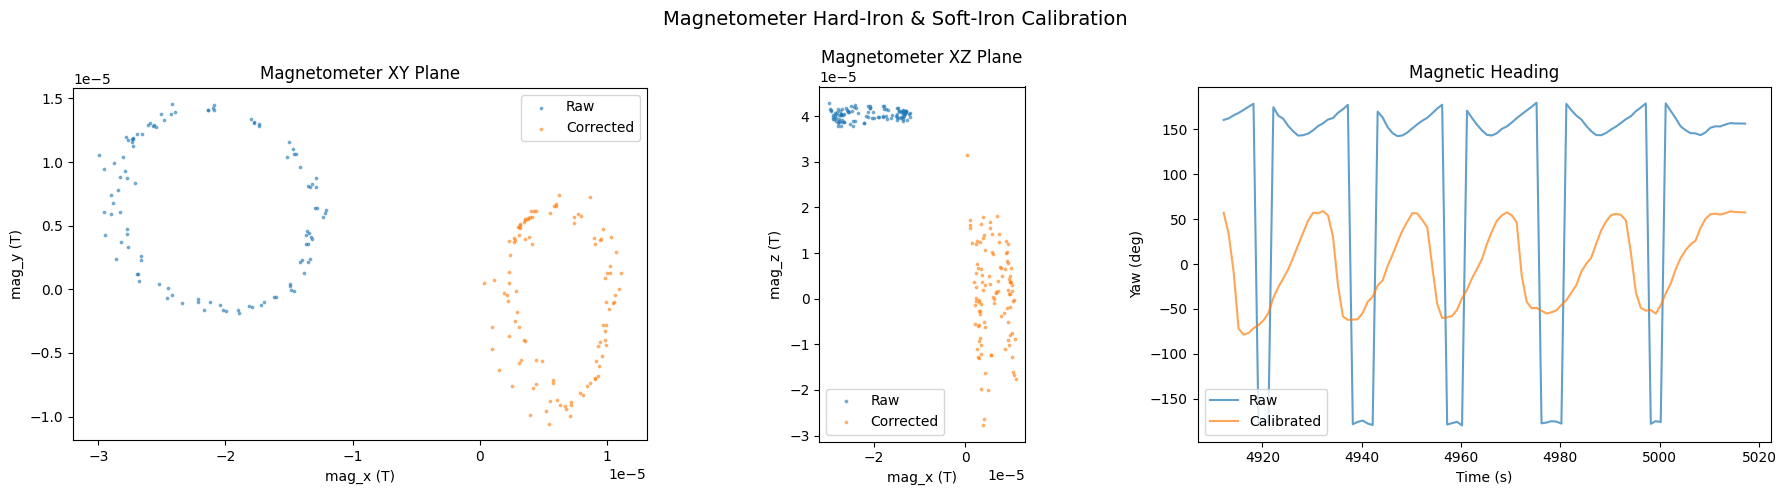

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XY plane — most important for heading
axes[0].scatter(mag[:, 0], mag[:, 1], s=3, alpha=0.5, label='Raw')
axes[0].scatter(mag_corrected[:, 0], mag_corrected[:, 1], s=3, alpha=0.5, label='Corrected')
axes[0].set_xlabel('mag_x (T)'); axes[0].set_ylabel('mag_y (T)')
axes[0].set_aspect('equal')
axes[0].legend()
axes[0].set_title('Magnetometer XY Plane')

# XZ plane
axes[1].scatter(mag[:, 0], mag[:, 2], s=3, alpha=0.5, label='Raw')
axes[1].scatter(mag_corrected[:, 0], mag_corrected[:, 2], s=3, alpha=0.5, label='Corrected')
axes[1].set_xlabel('mag_x (T)'); axes[1].set_ylabel('mag_z (T)')
axes[1].set_aspect('equal')
axes[1].legend()
axes[1].set_title('Magnetometer XZ Plane')

# Yaw comparison
yaw_raw = np.degrees(np.arctan2(mag[:, 1], mag[:, 0]))
yaw_cal = np.degrees(np.arctan2(mag_corrected[:, 1], mag_corrected[:, 0]))
axes[2].plot(df_circle['time_s'], yaw_raw, label='Raw', alpha=0.7)
axes[2].plot(df_circle['time_s'], yaw_cal, label='Calibrated', alpha=0.7)
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Yaw (deg)')
axes[2].legend()
axes[2].set_title('Magnetic Heading')

plt.suptitle('Magnetometer Hard-Iron & Soft-Iron Calibration', fontsize=14)
plt.tight_layout()
plt.savefig('images/mag_calibration_report.png', dpi=150, bbox_inches='tight')
plt.show()

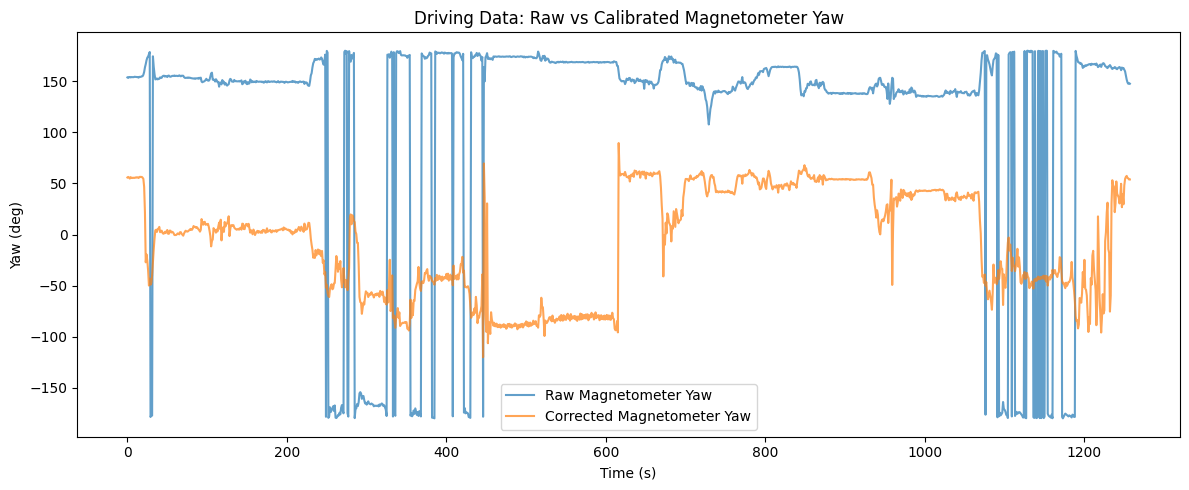

In [38]:
# Apply calibration from circle data to the driving data
mag_drive = df_drive[['mag_x', 'mag_y', 'mag_z']].values
mag_drive_corrected = (W @ (mag_drive - hard_iron).T).T

# Compute yaw from magnetometer
yaw_mag_raw = np.degrees(np.arctan2(mag_drive[:, 1], mag_drive[:, 0]))
yaw_mag_cal = np.degrees(np.arctan2(mag_drive_corrected[:, 1], mag_drive_corrected[:, 0]))

# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(df_drive['time_s'], yaw_mag_raw, label='Raw Magnetometer Yaw', alpha=0.7)
plt.plot(df_drive['time_s'], yaw_mag_cal, label='Corrected Magnetometer Yaw', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Yaw (deg)')
plt.legend()
plt.title('Driving Data: Raw vs Calibrated Magnetometer Yaw')
plt.tight_layout()
plt.savefig('images/driving_mag_yaw_comparison.png', dpi=150)
plt.show()

# Store corrected yaw in the dataframe for all further analysis
df_drive['mag_yaw'] = yaw_mag_cal